In [2]:
import h5py
import requests
import matplotlib.pyplot as plt
import numpy as np
import time

In [3]:
key = "api_key.txt"

with open(key) as file :
    api_key = file.read()


In [4]:
baseUrl = 'http://www.tng-project.org/api/'
headers = {"api-key":f"{api_key}"}

def get(path, params=None):
    # make HTTP GET request to path
    r = requests.get(path, params=params, headers=headers)

    # raise exception if response code is not HTTP SUCCESS (200)
    r.raise_for_status()

    if r.headers['content-type'] == 'application/json':
        return r.json() # parse json responses automatically
    
    if 'content-disposition' in r.headers:
        filename = r.headers['content-disposition'].split("filename=")[1]
        with open(filename, 'wb') as f:
            f.write(r.content)
        return filename # return the filename string
    
    return r

In [5]:
data = np.load("tng300-1_z0_positions.npz")
pos = np.column_stack([data["x_pos"], data["y_pos"], data["z_pos"]])
print("loaded", len(pos), "subhalos")

loaded 14485709 subhalos


In [7]:
np.random.seed(42)

n_data = 5000
idx = np.random.choice(len(pos), size=min(n_data, len(pos)), replace=False)
data_points = pos[idx]

boxsize = 302600 # tng300-1 box = 302.6 Mpc/h = 302600 ckpc/h
n_random = 3 * len(data_points)
random_points = np.random.rand(n_random, 3) * boxsize

#need to have same dimensionality in y and z
bins = np.linspace(0.1, 1, 100) * boxsize
bin_centers = (bins)

def count_pairs(points1, points2, bins):
    pair_counts = np.zeros(len(bins) - 1)
    
    for i in range(len(points1)):
        distances_sq = np.sum((points1[i] - points2) ** 2, axis=1)
        counts, _ = np.histogram(np.sqrt(distances_sq), bins = bins)
        pair_counts += counts

    return pair_counts
        
dd = count_pairs(data_points, data_points, bins)
dr = count_pairs(data_points, random_points, bins)
rr = count_pairs(random_points, random_points, bins)


#get the num of points in each catalog
nD = len(data_points)
nR = len(random_points)

dd = dd / (nD * (nD - 1)/2)
dr = dr / (nD * nR)
rr = rr / (nR * (nR - 1)/2)

In [8]:
# COMPUTE THE 2PCF USING LANDY-SZALAY ESTIMATOR
#xi_unnormalized = (d - r)**2 = (d*d - d*r - r*d + r*r) = (dd - 2dr + rr)

xi = np.zeros_like(dd, dtype=float)
valid_bins = rr != 0
xi[valid_bins] = (dd[valid_bins] - 2 * dr[valid_bins] + rr[valid_bins]) / rr[valid_bins]
xi[~valid_bins] = np.nan # assign NaN where rr = 0

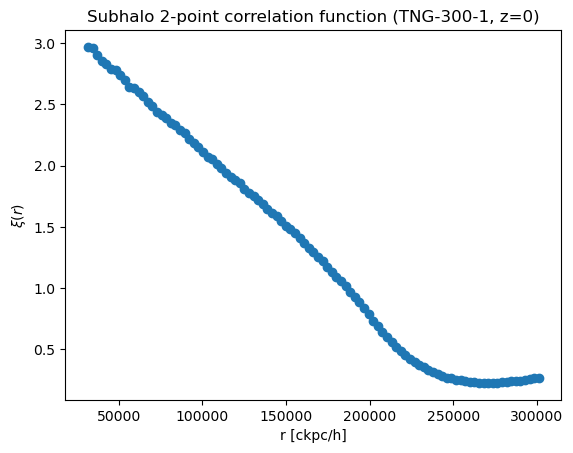

In [10]:
centers = 0.5 * (bins[:-1] + bins[1:])

plt.plot(centers, xi, "o-")
plt.xlabel("r [ckpc/h]")
plt.ylabel(r"$\xi(r)$")
plt.title("Subhalo 2-point correlation function (TNG-300-1, z=0)")
plt.show()

# voids = 2pcf value of < min of 2pcf graph below(maybe 0.9) (0.5 for extreme, aka no objects near)

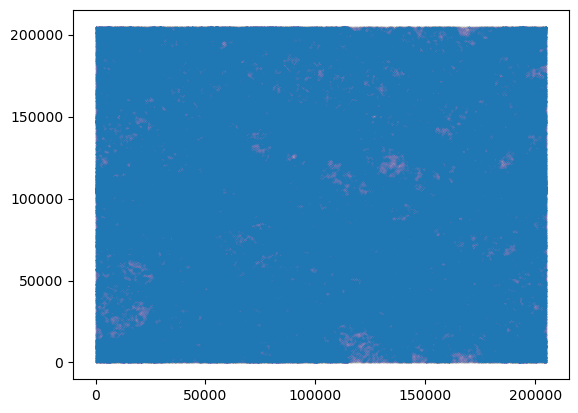

In [12]:
plt.plot(pos[:, 0], pos[:, 1], 'o', markersize=0.00179)
plt.show()

#search up how to do a 3d plot to visualize the voids

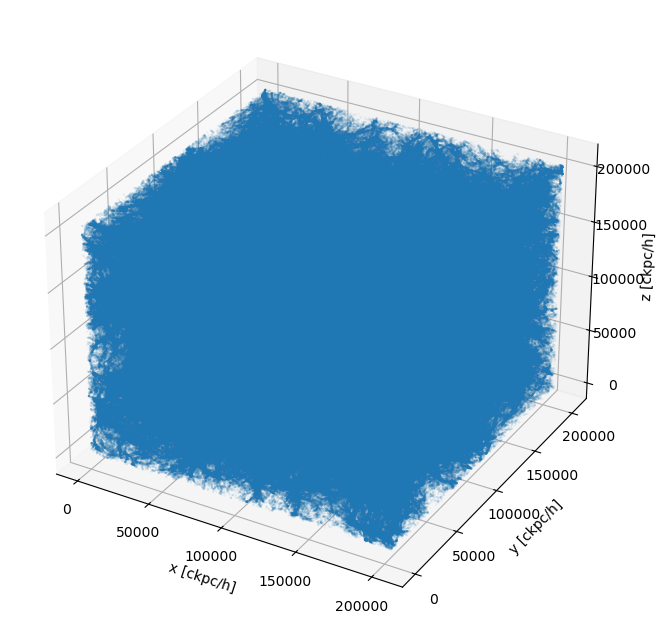

In [13]:
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(projection="3d")
ax.scatter(pos[:, 0], pos[:, 1], pos[:, 2], s=0.00179)
ax.set_xlabel("x [ckpc/h]")
ax.set_ylabel("y [ckpc/h]")
ax.set_zlabel("z [ckpc/h]")
plt.show()

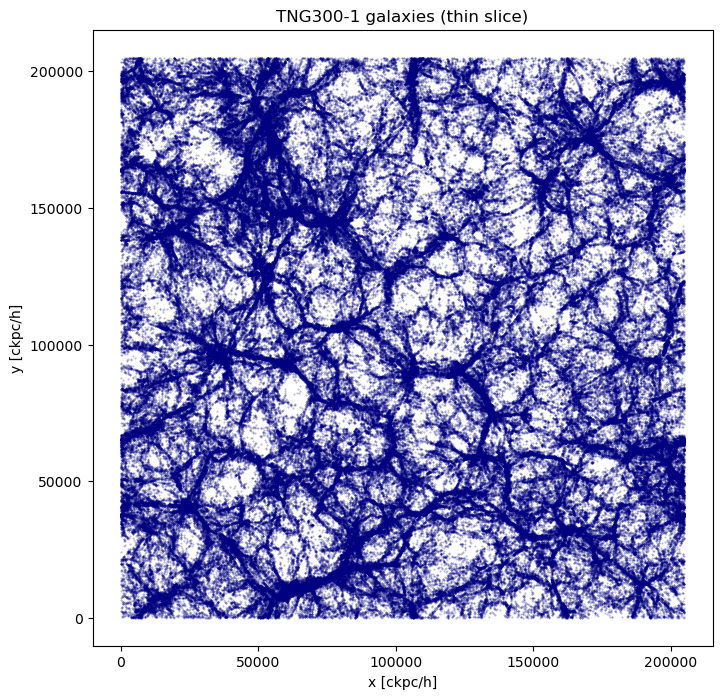

In [13]:
z = pos[:, 2]
slice_mask = (z > 100000) & (z < 108000) # this is around 4% of the z axis
pos_slice = pos[slice_mask]

# plot them
fig, ax = plt.subplots(figsize=(8,8))
plt.scatter(pos_slice[:, 0], pos_slice[:, 1], s=0.2, alpha=0.3, color="navy")
plt.xlabel("x [ckpc/h]")
plt.ylabel("y [ckpc/h]")
plt.title("TNG300-1 galaxies (thin slice)")
plt.savefig("tng300-1 slice galaxy plot.png")
plt.show()

In [14]:
ax.set_xlim(0, 205000)
ax.set_ylim(0, 205000)
ax.axis("off")
fig.subplots_adjust(left=0, right=1, top=1, bottom=0)
fig.savefig("clean_slice.png")  